# 04 — Transformer Full Training — SignBridge

This notebook fine-tunes a Transformer-based SignBridge model using the processed landmark dataset generated in `00_Preprocessing.ipynb`.

The notebook:
- Loads normalized train/validation/test landmark arrays
- Reuses saved label mappings and sequence lengths
- Builds a Transformer V3 architecture for full-sign classification
- Applies class weighting and data augmentation during training
- Evaluates Top-1 and Top-5 accuracy on validation/test splits
- Creates training curves, per-class accuracy analysis, and confusion matrix plots
- Saves checkpoints, deployment bundles, graphs, and ONNX exports into standardized project folders


## 1. Setup

In [ ]:
# ============================================================
# CELL 1 — Notebook Setup, Imports, and Path Configuration
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os
import sys
import json
import time
import random
import copy
import math
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# Change this only if your project folder is somewhere else.
PROJECT_ROOT = '/content/drive/MyDrive/UChicago/Masters/Spring/ADSP 31018/SignBridge'

SRC_DIR = os.path.join(PROJECT_ROOT, 'src')

DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
EXTERNAL_DIR = os.path.join(DATA_DIR, 'external')
PROCESSED_DIR = os.path.join(DATA_DIR, 'processed')

MODEL_DIR = os.path.join(PROJECT_ROOT, 'models')
CHECKPOINT_DIR = os.path.join(MODEL_DIR, 'checkpoints')
LOG_DIR = os.path.join(MODEL_DIR, 'logs')
ONNX_DIR = os.path.join(MODEL_DIR, 'onnx')

RESULTS_DIR = os.path.join(PROJECT_ROOT, 'results')
GRAPH_DIR = os.path.join(RESULTS_DIR, 'graphs')
REPORT_DIR = os.path.join(RESULTS_DIR, 'reports')
TABLE_DIR = os.path.join(RESULTS_DIR, 'tables')

# Processed dataset folder created by 00_Preprocessing.ipynb
INPUT_DIR = PROCESSED_DIR

for folder in [
    SRC_DIR,
    DATA_DIR,
    EXTERNAL_DIR,
    PROCESSED_DIR,
    INPUT_DIR,
    MODEL_DIR,
    CHECKPOINT_DIR,
    LOG_DIR,
    ONNX_DIR,
    RESULTS_DIR,
    GRAPH_DIR,
    REPORT_DIR,
    TABLE_DIR,
]:
    os.makedirs(folder, exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Backward-compatible aliases for older code cells
CKPT_DIR = CHECKPOINT_DIR

print('Project root:', PROJECT_ROOT)
print('Processed input dir:', INPUT_DIR)
print('Checkpoint dir:', CHECKPOINT_DIR)
print('Log dir:', LOG_DIR)
print('ONNX dir:', ONNX_DIR)
print('Graph dir:', GRAPH_DIR)
print('Report dir:', REPORT_DIR)


Mounted at /content/drive


In [ ]:
# ============================================================
# CELL 2 — Check GPU Runtime and VRAM
# ============================================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)
if device.type == 'cuda':
    print("GPU:  ", torch.cuda.get_device_name(0))
    print("VRAM: ", torch.cuda.get_device_properties(0).total_memory / 1e9, "GB")

Device: cuda
GPU:   NVIDIA RTX PRO 6000 Blackwell Server Edition
VRAM:  101.974081536 GB


## 2. Load Data

In [ ]:
# ============================================================
# CELL 3 — Inspect Processed Dataset Folder
# ============================================================

print(os.listdir(INPUT_DIR))

['X_train.npz', 'X_val.npz', 'X_test.npz', 'X_train_norm.npz', 'X_val_norm.npz', 'X_test_norm.npz', 'y_train.npy', 'y_val.npy', 'y_test.npy', 'lengths_train.npy', 'lengths_val.npy', 'lengths_test.npy', 'feat_mean.npy', 'feat_std.npy', 'metadata.json', 'class_weights_25.npy', 'best_pilot25_MLP.pt', 'best_pilot25_CNN.pt', 'best_pilot25_LSTM.pt', 'best_pilot25_GRU.pt', 'best_pilot25_CNN_LSTM.pt', 'best_pilot25_CNN_GRU.pt', 'best_pilot25_BiLSTM_Attention.pt', 'best_pilot25_TCN.pt', 'best_pilot25_Transformer.pt', 'best_pilot25_CNN_Transformer.pt', 'ablation_pilot25_all_models.csv', 'sign_model_pilot25_CNN.onnx.data', 'sign_model_pilot25_CNN.onnx', 'pilot25_training_summary.txt', 'pilot25_label_map.json', 'full250_label_map.json', 'class_weights_250.npy', 'best_full250_StrongCNN.pt', 'history_full250_StrongCNN.csv', 'best_full250_StrongCNN_GRU.pt']


In [ ]:
# ============================================================
# CELL 4 — Define Helper for Loading Processed Files
# ============================================================

def load_processed_file(fname):
    path = os.path.join(INPUT_DIR, fname)

    if os.path.exists(path):
        return path

    raise FileNotFoundError(f'Could not find {fname} in INPUT_DIR: {INPUT_DIR}')

In [ ]:
# ============================================================
# CELL 5 — Load Normalized Arrays, Labels, and Sequence Lengths
# ============================================================

X_train = np.load(os.path.join(INPUT_DIR, 'X_train_norm.npz'))['data']
X_val   = np.load(os.path.join(INPUT_DIR, 'X_val_norm.npz'))['data']
X_test  = np.load(os.path.join(INPUT_DIR, 'X_test_norm.npz'))['data']

y_train       = np.load(load_processed_file('y_train.npy'))
y_val         = np.load(load_processed_file('y_val.npy'))
y_test        = np.load(load_processed_file('y_test.npy'))

lengths_train = np.load(load_processed_file('lengths_train.npy'))
lengths_val   = np.load(load_processed_file('lengths_val.npy'))
lengths_test  = np.load(load_processed_file('lengths_test.npy'))

print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)

X_train: (55642, 96, 708)
X_val:   (9291, 96, 708)
X_test:  (11826, 96, 708)


In [ ]:
# ============================================================
# CELL 6 — Load Metadata and Label Mappings
# ============================================================

with open(load_processed_file('metadata.json')) as f:
    metadata = json.load(f)

idx_to_sign = {int(k): v for k, v in metadata['label_to_word'].items()}
sign_to_idx = {v: k for k, v in idx_to_sign.items()}

N_CLASSES  = len(idx_to_sign)
SEQ_LEN    = X_train.shape[1]
N_FEATURES = X_train.shape[2]

print(f"Classes:         {N_CLASSES}")
print(f"Sequence Length: {SEQ_LEN}")
print(f"Features:        {N_FEATURES}")

Classes:         250
Sequence Length: 96
Features:        708


In [ ]:
# ============================================================
# CELL 7 — Define Landmark Feature Dimensions
# ============================================================

# ── Adjust if your feature ordering differs ────────────────────────────────────
POSE_DIM  = 132
LHAND_DIM = 63
RHAND_DIM = 63
FACE_DIM  = N_FEATURES - POSE_DIM - LHAND_DIM - RHAND_DIM

POSE_START  = 0
LHAND_START = POSE_DIM
RHAND_START = POSE_DIM + LHAND_DIM
FACE_START  = POSE_DIM + LHAND_DIM + RHAND_DIM

assert POSE_DIM + LHAND_DIM + RHAND_DIM + FACE_DIM == N_FEATURES
print(f"Pose:       [{POSE_START}:{LHAND_START}]  → {POSE_DIM} features")
print(f"Left hand:  [{LHAND_START}:{RHAND_START}]  → {LHAND_DIM} features")
print(f"Right hand: [{RHAND_START}:{FACE_START}] → {RHAND_DIM} features")
print(f"Face:       [{FACE_START}:{N_FEATURES}] → {FACE_DIM} features")

Pose:       [0:132]  → 132 features
Left hand:  [132:195]  → 63 features
Right hand: [195:258] → 63 features
Face:       [258:708] → 450 features


## 3. Data Split Diagnostics

**Run this before training.** The V2 results showed val=71% but test=40% — a gap that large usually means the splits have different class distributions or difficulty levels.

=== Split sizes ===
Train:  55642  (72.5%)
Val:     9291  (12.1%)
Test:   11826  (15.4%)

Classes with 0 samples in val:  0
Classes with 0 samples in test: 0

Min/max samples per class:
  Train: 127 – 281
  Val:   16   – 57
  Test:  13  – 65


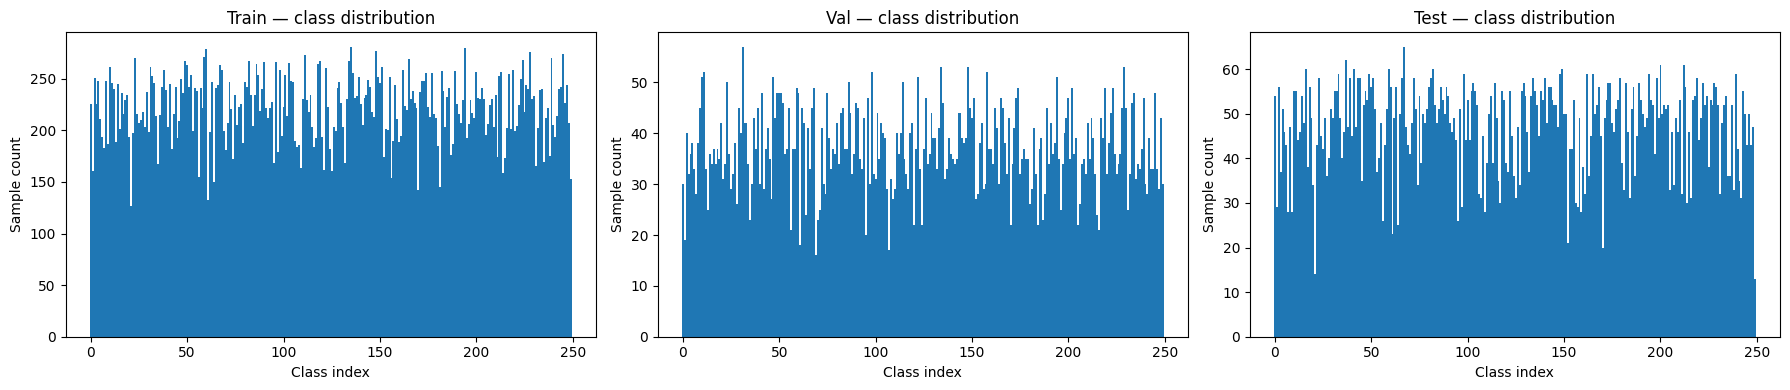


Per-class count correlation (train vs val):  0.7143
Per-class count correlation (train vs test): 0.7952
(Values close to 1.0 = balanced splits. Low values = distribution mismatch.)


In [ ]:
# ============================================================
# CELL 8 — Summarize Split Sizes and Plot Class Distributions
# ============================================================

print("=== Split sizes ===")
print(f"Train: {len(y_train):>6}  ({len(y_train)/( len(y_train)+len(y_val)+len(y_test))*100:.1f}%)")
print(f"Val:   {len(y_val):>6}  ({len(y_val)  /( len(y_train)+len(y_val)+len(y_test))*100:.1f}%)")
print(f"Test:  {len(y_test):>6}  ({len(y_test) /( len(y_train)+len(y_val)+len(y_test))*100:.1f}%)")

# Per-class sample counts in each split
train_counts = np.bincount(y_train, minlength=N_CLASSES)
val_counts   = np.bincount(y_val,   minlength=N_CLASSES)
test_counts  = np.bincount(y_test,  minlength=N_CLASSES)

print(f"\nClasses with 0 samples in val:  {(val_counts  == 0).sum()}")
print(f"Classes with 0 samples in test: {(test_counts == 0).sum()}")
print(f"\nMin/max samples per class:")
print(f"  Train: {train_counts.min()} – {train_counts.max()}")
print(f"  Val:   {val_counts.min()}   – {val_counts.max()}")
print(f"  Test:  {test_counts.min()}  – {test_counts.max()}")

# Visual check
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, (counts, name) in zip(axes, [
    (train_counts, 'Train'),
    (val_counts,   'Val'),
    (test_counts,  'Test'),
]):
    ax.bar(range(N_CLASSES), counts, width=1.0)
    ax.set_title(f'{name} — class distribution')
    ax.set_xlabel('Class index')
    ax.set_ylabel('Sample count')
plt.tight_layout()
plt.savefig(os.path.join(GRAPH_DIR, 'split_distributions.png'), dpi=150)
plt.show()

# Correlation between per-class counts across splits
corr_tv = np.corrcoef(train_counts, val_counts)[0, 1]
corr_tt = np.corrcoef(train_counts, test_counts)[0, 1]
print(f"\nPer-class count correlation (train vs val):  {corr_tv:.4f}")
print(f"Per-class count correlation (train vs test): {corr_tt:.4f}")
print("(Values close to 1.0 = balanced splits. Low values = distribution mismatch.)")

## 4. Dataset & Augmentation

Key additions vs V2:
- **Random temporal crop** — takes a contiguous 70–100% slice of the sequence
- **Feature masking** — randomly zeros an entire body part stream (20% chance)
- Stronger noise (0.005), wider time stretch (0.6×–1.4×), more aggressive frame dropout (10%)

In [ ]:
# ============================================================
# CELL 9 — Define Dataset Class with Augmentation
# ============================================================

class SignDataset(Dataset):
    def __init__(self, X, y, lengths, augment=False):
        self.X       = torch.tensor(X,       dtype=torch.float32)
        self.y       = torch.tensor(y,       dtype=torch.long)
        self.lengths = torch.tensor(lengths, dtype=torch.long)
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x, y, l = self.X[idx], self.y[idx], self.lengths[idx]
        if self.augment:
            x, l = self._augment(x, l)
        return x, y, l

    def _augment(self, x, l):
        x     = x.clone()
        l_int = int(l.item())

        # ── Time stretch: wider range (0.6× – 1.4×) ───────────────────────────
        if torch.rand(1).item() < 0.7:
            rate    = 0.60 + torch.rand(1).item() * 0.80
            new_len = max(1, int(round(l_int * rate)))
            real    = x[:l_int]
            old_idx = torch.linspace(0, l_int - 1, new_len)
            lo      = old_idx.floor().long().clamp(0, l_int - 1)
            hi      = old_idx.ceil().long().clamp(0, l_int - 1)
            frac    = (old_idx - lo.float()).unsqueeze(1)
            stretched = real[lo] * (1 - frac) + real[hi] * frac
            out     = torch.zeros_like(x)
            keep    = min(new_len, x.shape[0])
            out[:keep] = stretched[:keep]
            x, l_int   = out, keep

        # ── Global Gaussian noise (stronger) ──────────────────────────────────
        if torch.rand(1).item() < 0.7:
            x[:l_int] += torch.randn(l_int, x.shape[1]) * 0.005

        # ── Hand-specific spatial jitter (stronger) ────────────────────────────
        if torch.rand(1).item() < 0.7:
            hand_slice = slice(LHAND_START, FACE_START)
            x[:l_int, hand_slice] += torch.randn(l_int, LHAND_DIM + RHAND_DIM) * 0.01

        # ── Frame dropout (10% of frames, up from 5%) ─────────────────────────
        if torch.rand(1).item() < 0.5:
            mask = torch.rand(l_int) < 0.10
            x[:l_int][mask] = 0.0

        # ── Random temporal crop (keep 70–100% of sequence) ───────────────────
        if torch.rand(1).item() < 0.5:
            crop_ratio = 0.70 + torch.rand(1).item() * 0.30
            crop_len   = max(1, int(l_int * crop_ratio))
            start      = random.randint(0, max(0, l_int - crop_len))
            cropped    = x[start:start + crop_len].clone()
            x          = torch.zeros_like(x)
            x[:crop_len] = cropped
            l_int        = crop_len

        # ── Feature masking: zero out one entire body part stream ──────────────
        if torch.rand(1).item() < 0.2:
            part_slices = {
                'pose':  slice(POSE_START,  LHAND_START),
                'lhand': slice(LHAND_START, RHAND_START),
                'rhand': slice(RHAND_START, FACE_START),
                'face':  slice(FACE_START,  None),
            }
            part = random.choice(list(part_slices.keys()))
            x[:l_int, part_slices[part]] = 0.0

        # ── Mirror left ↔ right hand ───────────────────────────────────────────
        # Disable if your dataset has handedness-sensitive signs
        if torch.rand(1).item() < 0.3:
            lh = x[:, LHAND_START:RHAND_START].clone()
            rh = x[:, RHAND_START:FACE_START].clone()
            x[:, LHAND_START:RHAND_START] = rh
            x[:, RHAND_START:FACE_START]  = lh
            x[:, LHAND_START:FACE_START:3] = 1.0 - x[:, LHAND_START:FACE_START:3]

        return x, torch.tensor(l_int, dtype=torch.long)

In [ ]:
# ============================================================
# CELL 10 — Create Train Validation and Test DataLoaders
# ============================================================

BATCH = 128

train_dataset = SignDataset(X_train, y_train, lengths_train, augment=True)
val_dataset   = SignDataset(X_val,   y_val,   lengths_val,   augment=False)
test_dataset  = SignDataset(X_test,  y_test,  lengths_test,  augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

x_batch, y_batch, l_batch = next(iter(train_loader))
print("Batch X:",       x_batch.shape)
print("Batch y:",       y_batch.shape)
print("Batch lengths:", l_batch.shape)

Batch X: torch.Size([128, 96, 708])
Batch y: torch.Size([128])
Batch lengths: torch.Size([128])


## 5. Model — SignTransformerV3

**Key changes from V2:**
- `d_model=512` (down from 768), `num_layers=4` (down from 6) — reduce parameter count relative to dataset size
- `dropout=0.4` (up from 0.2), `drop_path=0.2` (up from 0.1) — much stronger regularization
- Architecture structure identical to V2 (body-part projections, pre-norm, stochastic depth)

In [ ]:
# ============================================================
# CELL 11 — Define Transformer V3 Architecture
# ============================================================

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=200, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])


class StochasticDepthTransformerEncoder(nn.Module):
    def __init__(self, encoder_layer, num_layers, drop_path_rate=0.1):
        super().__init__()
        self.layers = nn.ModuleList(
            [encoder_layer for _ in range(num_layers)]
        )
        self.drop_probs = [
            drop_path_rate * i / max(num_layers - 1, 1)
            for i in range(num_layers)
        ]

    def forward(self, x, src_key_padding_mask=None):
        for layer, p in zip(self.layers, self.drop_probs):
            if self.training and p > 0 and torch.rand(1).item() < p:
                continue
            x = layer(x, src_key_padding_mask=src_key_padding_mask)
        return x


class SignTransformerV3(nn.Module):
    def __init__(
        self,
        n_classes,
        pose_dim   = POSE_DIM,
        lhand_dim  = LHAND_DIM,
        rhand_dim  = RHAND_DIM,
        face_dim   = FACE_DIM,
        d_model    = 512,
        nhead      = 8,
        num_layers = 4,
        dim_ff     = 2048,
        dropout    = 0.4,
        drop_path  = 0.2,
    ):
        super().__init__()
        assert d_model % 4 == 0
        q = d_model // 4

        # ── Body-part projection heads ─────────────────────────────────────────
        self.pose_proj  = nn.Sequential(nn.Linear(pose_dim,  q), nn.LayerNorm(q), nn.GELU(), nn.Dropout(dropout))
        self.lhand_proj = nn.Sequential(nn.Linear(lhand_dim, q), nn.LayerNorm(q), nn.GELU(), nn.Dropout(dropout))
        self.rhand_proj = nn.Sequential(nn.Linear(rhand_dim, q), nn.LayerNorm(q), nn.GELU(), nn.Dropout(dropout))
        self.face_proj  = nn.Sequential(nn.Linear(face_dim,  q), nn.LayerNorm(q), nn.GELU(), nn.Dropout(dropout))

        self.fusion_norm = nn.LayerNorm(d_model)
        self.input_drop  = nn.Dropout(dropout)
        self.pos_enc     = PositionalEncoding(d_model, dropout=dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model        = d_model,
            nhead          = nhead,
            dim_feedforward= dim_ff,
            dropout        = dropout,
            batch_first    = True,
            norm_first     = True,
            activation     = 'gelu',
        )
        self.transformer = StochasticDepthTransformerEncoder(
            encoder_layer, num_layers, drop_path_rate=drop_path
        )

        # ── Classifier head ────────────────────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, n_classes),
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x, lengths):
        pose  = self.pose_proj( x[:, :, POSE_START :LHAND_START])
        lhand = self.lhand_proj(x[:, :, LHAND_START:RHAND_START])
        rhand = self.rhand_proj(x[:, :, RHAND_START:FACE_START ])
        face  = self.face_proj( x[:, :, FACE_START :]           )

        x = torch.cat([pose, lhand, rhand, face], dim=-1)
        x = self.fusion_norm(x)
        x = self.input_drop(x)
        x = self.pos_enc(x)

        B, S, _ = x.shape
        pad_mask = torch.arange(S, device=x.device).unsqueeze(0) >= lengths.unsqueeze(1)

        x = self.transformer(x, src_key_padding_mask=pad_mask)

        valid = (~pad_mask).unsqueeze(-1).float()
        x = (x * valid).sum(dim=1) / valid.sum(dim=1).clamp(min=1)

        return self.classifier(x)

In [ ]:
# ============================================================
# CELL 12 — Initialize Transformer V3 Model
# ============================================================

model = SignTransformerV3(
    n_classes  = N_CLASSES,
    d_model    = 512,
    nhead      = 8,
    num_layers = 4,
    dim_ff     = 2048,
    dropout    = 0.4,
    drop_path  = 0.2,
).to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params:     {total_params/1e6:.1f}M")
print(f"Trainable params: {trainable_params/1e6:.1f}M")

Total params:     3.4M
Trainable params: 3.4M


## 6. Loss, Optimizer & Scheduler

In [ ]:
# ============================================================
# CELL 13 — Compute Balanced Class Weights
# ============================================================

classes      = np.arange(N_CLASSES)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
).astype(np.float32)
weight_tensor = torch.tensor(class_weights, device=device)

# Higher label smoothing — helps with 250 visually similar classes
criterion = nn.CrossEntropyLoss(weight=weight_tensor, label_smoothing=0.15)

# Higher weight decay — key regularizer alongside dropout
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-3,
    betas=(0.9, 0.999),
)

EPOCHS_WARMUP = 10
MAX_EPOCHS    = 120   # early stopping will cut this short
PATIENCE      = 10    # stop if val top-1 doesn't improve for 10 epochs

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr          = 3e-4,
    steps_per_epoch = len(train_loader),
    epochs          = MAX_EPOCHS,
    pct_start       = EPOCHS_WARMUP / MAX_EPOCHS,
    anneal_strategy = 'cos',
)

print(f"Warmup epochs:    {EPOCHS_WARMUP}")
print(f"Max epochs:       {MAX_EPOCHS} (early stopping patience={PATIENCE})")

Warmup epochs:    10
Max epochs:       120 (early stopping patience=10)


## 7. Training Utilities

In [ ]:
# ============================================================
# CELL 14 — Define Top-K Accuracy Helper
# ============================================================

def topk_accuracy(logits, labels, k=5):
    topk    = logits.topk(k, dim=1).indices
    correct = topk.eq(labels.unsqueeze(1).expand_as(topk))
    return correct.any(dim=1).float().mean().item()


def run_epoch(model, loader, criterion, optimizer=None, scheduler=None, train=True):
    model.train() if train else model.eval()
    total_loss, top1_correct, top5_correct, total = 0, 0, 0, 0

    with torch.set_grad_enabled(train):
        for x, y, lengths in loader:
            x, y, lengths = x.to(device), y.to(device), lengths.to(device)

            logits = model(x, lengths)
            loss   = criterion(logits, y)

            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                if scheduler is not None:
                    scheduler.step()

            preds = logits.argmax(dim=1)
            top1_correct += (preds == y).sum().item()
            top5_correct += topk_accuracy(logits, y, k=5) * y.size(0)
            total        += y.size(0)
            total_loss   += loss.item() * y.size(0)

    return total_loss / total, top1_correct / total, top5_correct / total

## 8. Training with Early Stopping

No Phase 3 — the best val checkpoint IS the final model.

In [ ]:
# ============================================================
# CELL 15 — Train Transformer and Save Best Checkpoint
# ============================================================

CKPT_PATH    = os.path.join(CHECKPOINT_DIR, 'best_transformer_v3.pt')
best_val_acc = 0.0
no_improve   = 0

history = {
    'train_loss': [], 'val_loss': [],
    'train_top1': [], 'val_top1': [],
    'train_top5': [], 'val_top5': [],
}

for epoch in range(1, MAX_EPOCHS + 1):
    t0 = time.time()

    train_loss, train_top1, train_top5 = run_epoch(
        model, train_loader, criterion, optimizer, scheduler, train=True
    )
    val_loss, val_top1, val_top5 = run_epoch(
        model, val_loader, criterion, train=False
    )

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_top1'].append(train_top1)
    history['val_top1'].append(val_top1)
    history['train_top5'].append(train_top5)
    history['val_top5'].append(val_top5)

    improved = val_top1 > best_val_acc
    if improved:
        best_val_acc = val_top1
        torch.save(model.state_dict(), CKPT_PATH)
        no_improve = 0
        tag = "  ← best"
    else:
        no_improve += 1
        tag = f"  (no improve {no_improve}/{PATIENCE})"

    phase = "warmup" if epoch <= EPOCHS_WARMUP else "main  "
    lr    = optimizer.param_groups[0]['lr']

    # Train/val gap warning
    gap = train_top1 - val_top1
    gap_flag = "  ⚠ overfit" if gap > 0.20 else ""

    print(
        f"[{phase}] Ep {epoch:03d} | "
        f"Loss {train_loss:.4f}/{val_loss:.4f} | "
        f"Top1 {train_top1:.3f}/{val_top1:.3f} (gap={gap:+.3f}) | "
        f"Top5 {train_top5:.3f}/{val_top5:.3f} | "
        f"LR {lr:.2e} | "
        f"{time.time()-t0:.1f}s{tag}{gap_flag}"
    )

    if no_improve >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch}.")
        break

print(f"\nBest val top-1: {best_val_acc:.4f}")

[warmup] Ep 001 | Loss 5.5396/5.5242 | Top1 0.004/0.005 (gap=-0.001) | Top5 0.023/0.031 | LR 1.91e-05 | 16.1s  ← best
[warmup] Ep 002 | Loss 5.4499/5.2775 | Top1 0.011/0.023 (gap=-0.012) | Top5 0.050/0.089 | LR 3.95e-05 | 13.5s  ← best
[warmup] Ep 003 | Loss 5.0868/4.7905 | Top1 0.037/0.086 (gap=-0.050) | Top5 0.141/0.285 | LR 7.14e-05 | 13.4s  ← best
[warmup] Ep 004 | Loss 4.7383/4.5933 | Top1 0.074/0.124 (gap=-0.051) | Top5 0.253/0.356 | LR 1.12e-04 | 13.4s  ← best
[warmup] Ep 005 | Loss 4.4907/4.3165 | Top1 0.111/0.177 (gap=-0.065) | Top5 0.347/0.455 | LR 1.56e-04 | 13.4s  ← best
[warmup] Ep 006 | Loss 4.2864/4.1149 | Top1 0.152/0.211 (gap=-0.059) | Top5 0.423/0.517 | LR 2.01e-04 | 13.3s  ← best
[warmup] Ep 007 | Loss 4.1284/3.9614 | Top1 0.186/0.248 (gap=-0.062) | Top5 0.479/0.558 | LR 2.41e-04 | 13.2s  ← best
[warmup] Ep 008 | Loss 3.9698/3.7835 | Top1 0.222/0.300 (gap=-0.077) | Top5 0.532/0.618 | LR 2.73e-04 | 13.3s  ← best
[warmup] Ep 009 | Loss 3.8330/3.7837 | Top1 0.259/0.294 

## 9. Training Curves

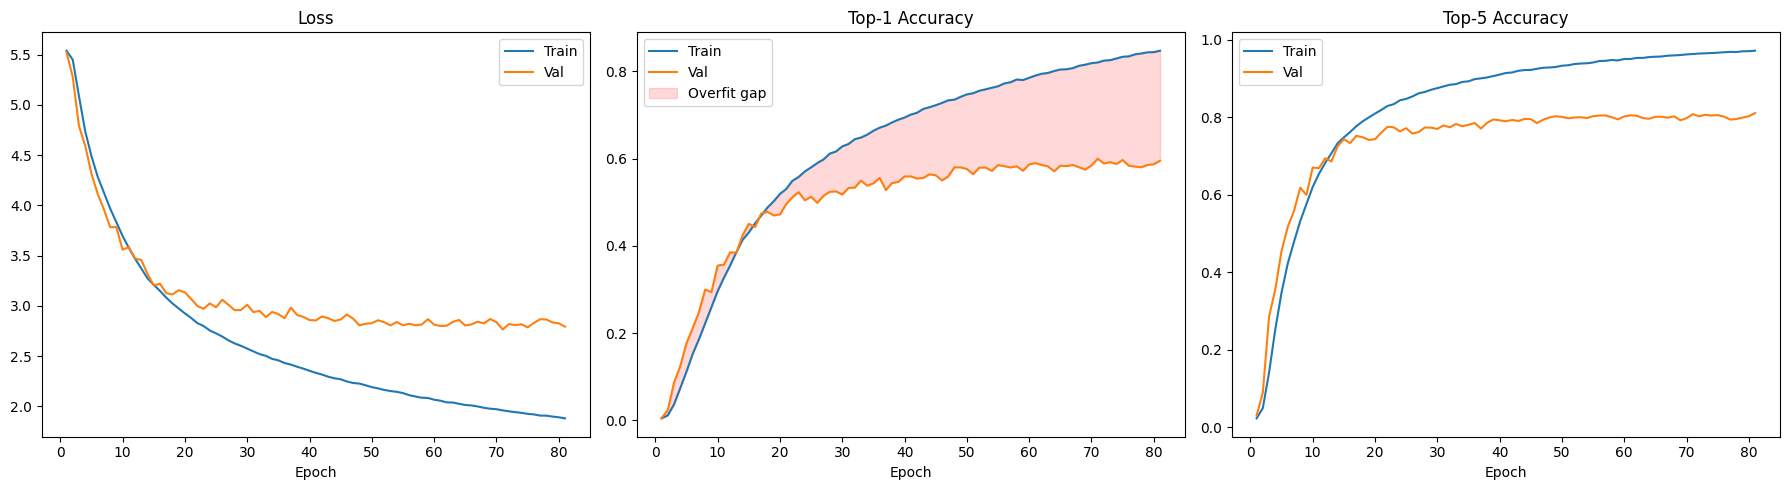

Final train/val gap: +0.2523
Best val top-1: 0.5998
⚠  Gap still >15% — consider increasing dropout further or reducing model size.


In [ ]:
# ============================================================
# CELL 16 — Plot Training and Validation Curves
# ============================================================

n_epochs = len(history['train_loss'])
epochs   = range(1, n_epochs + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs, history['train_loss'], label='Train')
axes[0].plot(epochs, history['val_loss'],   label='Val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(epochs, history['train_top1'], label='Train')
axes[1].plot(epochs, history['val_top1'],   label='Val')
# Shade the gap between train and val
axes[1].fill_between(
    epochs,
    history['val_top1'],
    history['train_top1'],
    alpha=0.15, color='red', label='Overfit gap'
)
axes[1].set_title('Top-1 Accuracy'); axes[1].legend(); axes[1].set_xlabel('Epoch')

axes[2].plot(epochs, history['train_top5'], label='Train')
axes[2].plot(epochs, history['val_top5'],   label='Val')
axes[2].set_title('Top-5 Accuracy'); axes[2].legend(); axes[2].set_xlabel('Epoch')

plt.tight_layout()
plt.savefig(os.path.join(GRAPH_DIR, 'training_curves_v3.png'), dpi=150)
plt.show()

# Print final gap summary
final_train = history['train_top1'][-1]
final_val   = history['val_top1'][-1]
print(f"Final train/val gap: {final_train - final_val:+.4f}")
print(f"Best val top-1: {best_val_acc:.4f}")
if final_train - final_val > 0.15:
    print("⚠  Gap still >15% — consider increasing dropout further or reducing model size.")
else:
    print("✓  Train/val gap is healthy.")

## 10. Final Evaluation on Test Set

In [ ]:
# ============================================================
# CELL 17 — Evaluate Best Transformer on Test Set
# ============================================================

model.load_state_dict(torch.load(CKPT_PATH))
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for x, y, lengths in test_loader:
        x, lengths = x.to(device), lengths.to(device)
        logits = model(x, lengths)
        probs  = torch.softmax(logits, dim=1).cpu()
        preds  = probs.argmax(dim=1)
        all_preds.extend(preds.tolist())
        all_labels.extend(y.tolist())
        all_probs.append(probs)

all_probs = torch.cat(all_probs, dim=0)

top1 = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
top5 = sum(
    l in all_probs[i].topk(5).indices.tolist()
    for i, l in enumerate(all_labels)
) / len(all_labels)

print(f"Test Top-1: {top1:.4f}  ({top1*100:.2f}%)")
print(f"Test Top-5: {top5:.4f}  ({top5*100:.2f}%)")
print(f"Val  Top-1: {best_val_acc:.4f}  ({best_val_acc*100:.2f}%)")
print(f"\nVal–Test gap: {best_val_acc - top1:+.4f}")
if best_val_acc - top1 > 0.10:
    print("⚠  Val–Test gap >10% — check split distributions (section 3) and look for data leakage.")
else:
    print("✓  Val–Test gap is healthy.")

Test Top-1: 0.6808  (68.08%)
Test Top-5: 0.8891  (88.91%)
Val  Top-1: 0.5998  (59.98%)

Val–Test gap: -0.0810
✓  Val–Test gap is healthy.


In [ ]:
# ============================================================
# CELL 18 — Analyze Per-Class Test Accuracy
# ============================================================

# Per-class accuracy — find worst performing signs
per_class_correct = np.zeros(N_CLASSES)
per_class_total   = np.zeros(N_CLASSES)

for pred, label in zip(all_preds, all_labels):
    per_class_total[label]   += 1
    per_class_correct[label] += int(pred == label)

per_class_acc = np.where(
    per_class_total > 0,
    per_class_correct / per_class_total,
    np.nan
)

# Bottom 20 worst classes
valid_mask  = ~np.isnan(per_class_acc)
worst_idx   = np.argsort(per_class_acc[valid_mask])[:20]
valid_idxs  = np.where(valid_mask)[0]

print("\n20 Worst-Performing Signs:")
print(f"{'Sign':<25} {'Acc':>6}  {'n_test':>6}")
print("-" * 40)
for idx in valid_idxs[worst_idx]:
    print(f"{idx_to_sign[idx]:<25} {per_class_acc[idx]:>6.3f}  {int(per_class_total[idx]):>6}")


20 Worst-Performing Signs:
Sign                         Acc  n_test
----------------------------------------
give                       0.077      26
snack                      0.096      52
nap                        0.100      50
tongue                     0.175      57
listen                     0.200      55
there                      0.226      31
awake                      0.236      55
pen                        0.250      52
glasswindow                0.255      51
cereal                     0.259      58
carrot                     0.274      62
go                         0.276      29
sleepy                     0.295      61
mouth                      0.300      60
stay                       0.303      33
backyard                   0.318      44
finger                     0.321      56
wet                        0.333      36
goose                      0.339      59
jacket                     0.355      31


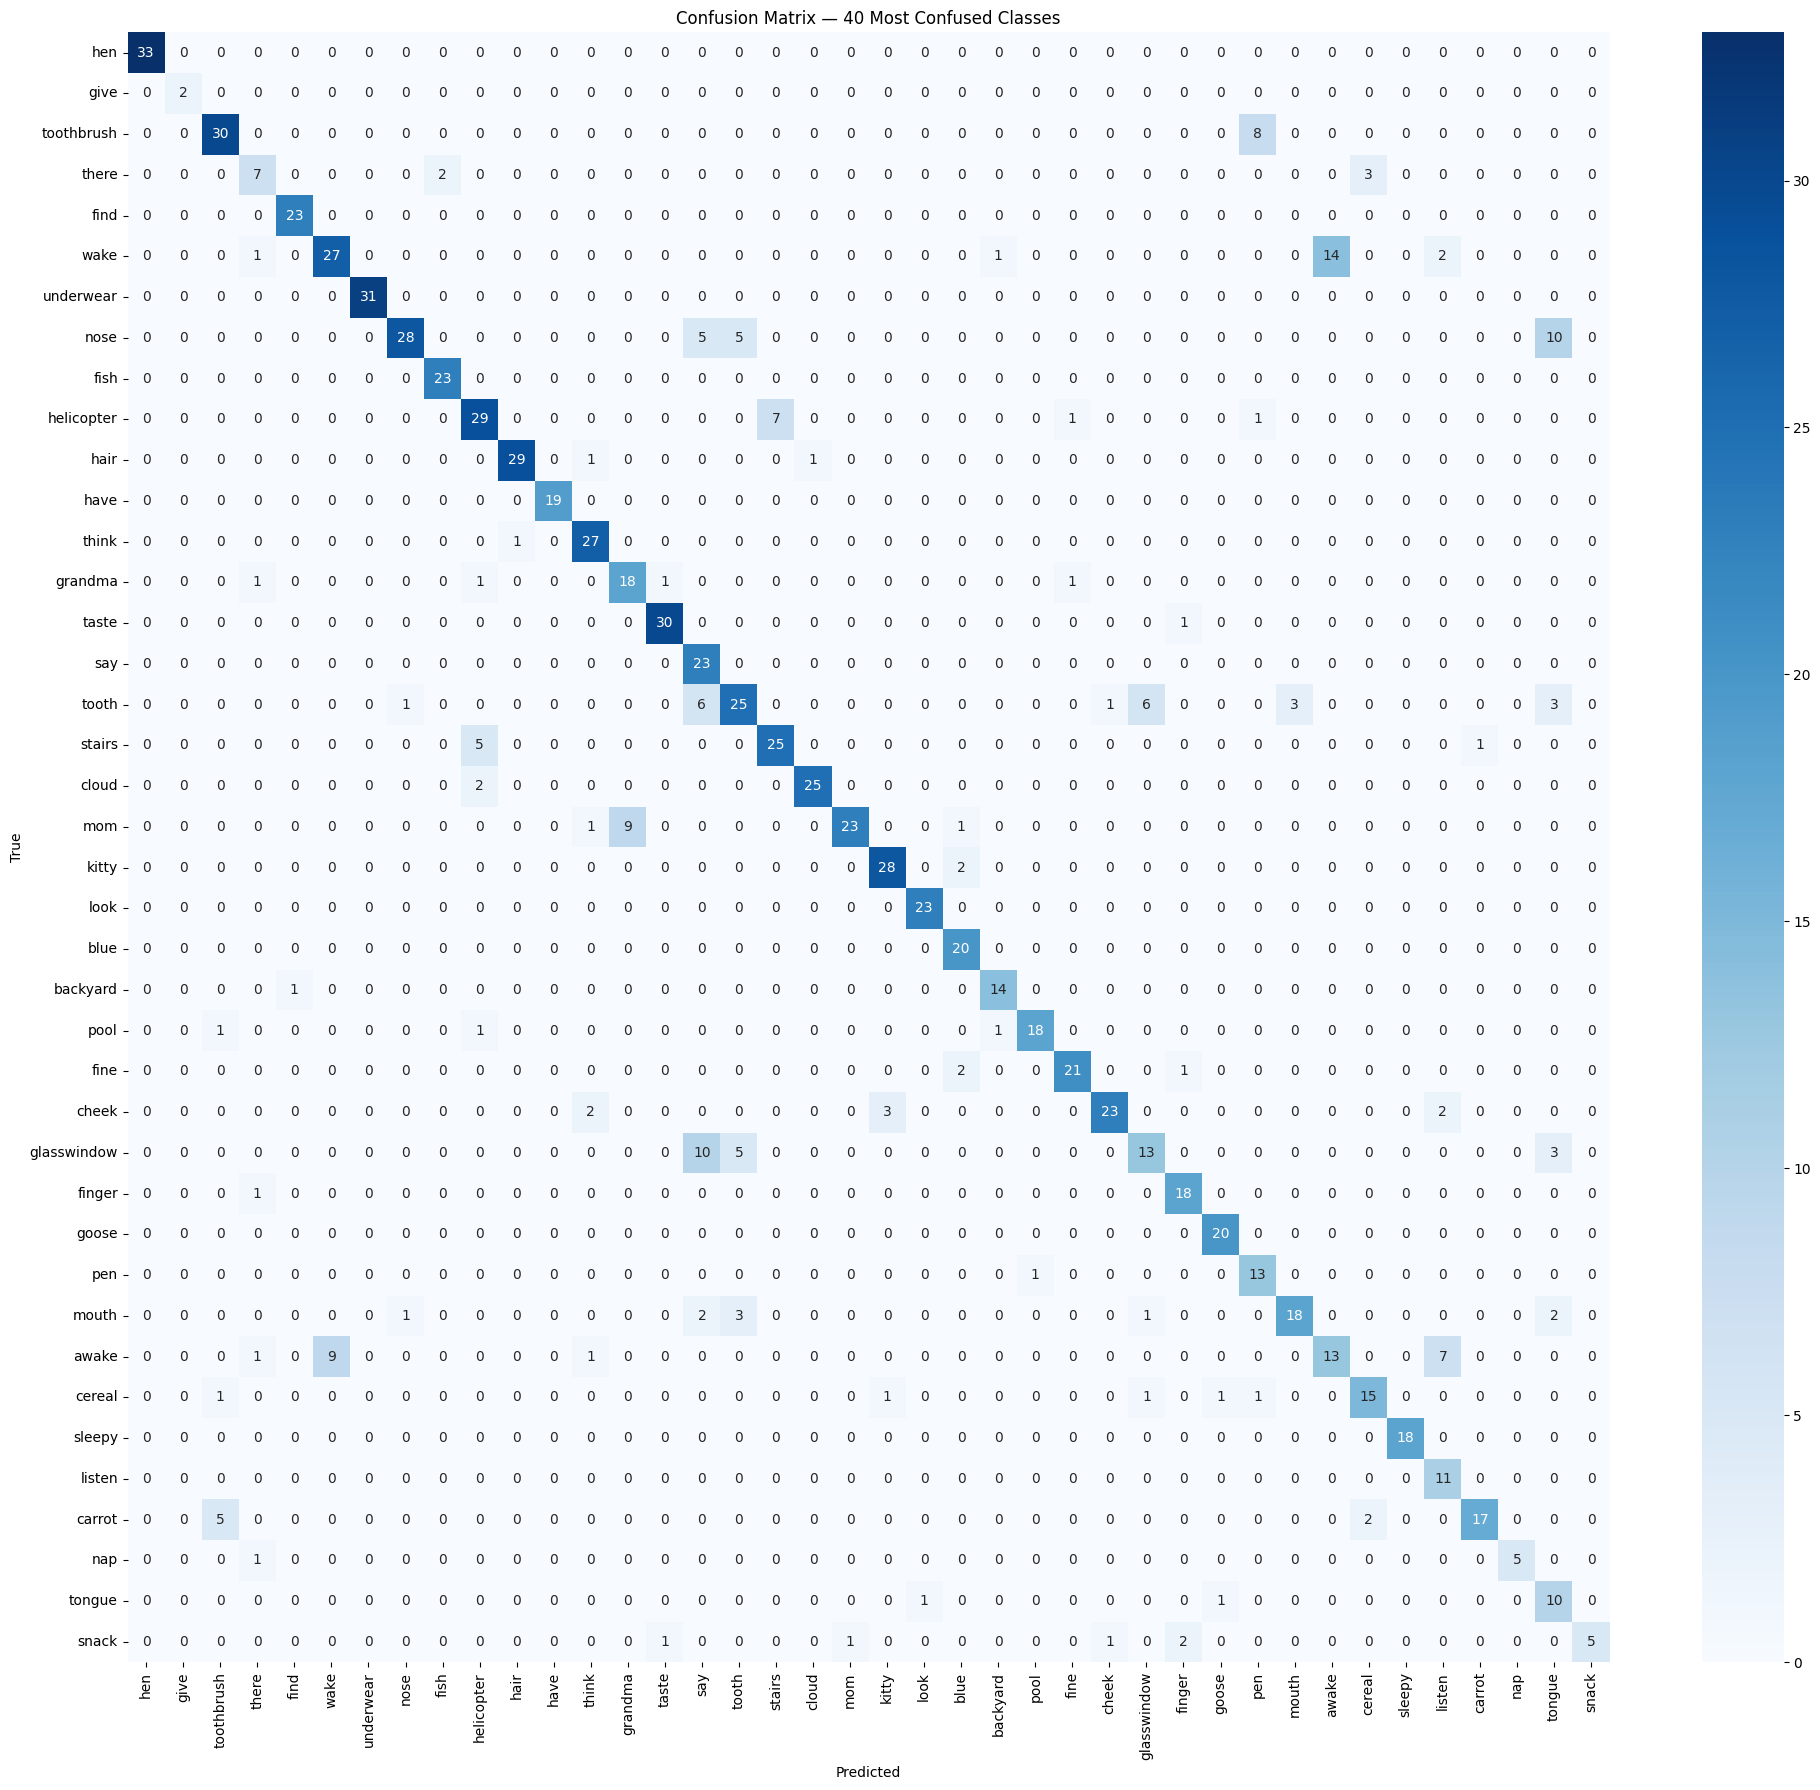

In [ ]:
# ============================================================
# CELL 19 — Plot Confusion Matrix for Common Classes
# ============================================================

# Confusion matrix — 40 most confused classes
cm = confusion_matrix(all_labels, all_preds)
off_diag  = cm.copy()
np.fill_diagonal(off_diag, 0)
top40_idx = np.argsort(off_diag.sum(axis=1))[-40:]
cm_sub    = cm[np.ix_(top40_idx, top40_idx)]

fig, ax = plt.subplots(figsize=(20, 18))
sns.heatmap(
    cm_sub, annot=True, fmt='d', cmap='Blues',
    xticklabels=[idx_to_sign[i] for i in top40_idx],
    yticklabels=[idx_to_sign[i] for i in top40_idx],
    ax=ax
)
ax.set_title('Confusion Matrix — 40 Most Confused Classes')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.xticks(rotation=90); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(GRAPH_DIR, 'confusion_matrix_v3.png'), dpi=150)
plt.show()

## 11. Inference on a Single MP4

In [ ]:
# ============================================================
# CELL 20 — Install MediaPipe Dependency
# ============================================================

!pip install mediapipe -q

In [ ]:
# ============================================================
# CELL 21 — Define MediaPipe Live-Inference Utilities
# ============================================================

import cv2
import mediapipe as mp

def extract_keypoints_from_results(results):
    pose = np.array([[lm.x, lm.y, lm.z, lm.visibility]
                     for lm in results.pose_landmarks.landmark]).flatten() \
           if results.pose_landmarks else np.zeros(POSE_DIM)

    lh = np.array([[lm.x, lm.y, lm.z]
                   for lm in results.left_hand_landmarks.landmark]).flatten() \
         if results.left_hand_landmarks else np.zeros(LHAND_DIM)

    rh = np.array([[lm.x, lm.y, lm.z]
                   for lm in results.right_hand_landmarks.landmark]).flatten() \
         if results.right_hand_landmarks else np.zeros(RHAND_DIM)

    n_face_lm = FACE_DIM // 3
    if results.face_landmarks:
        face_lm = results.face_landmarks.landmark[:n_face_lm]
        face = np.array([[lm.x, lm.y, lm.z] for lm in face_lm]).flatten()
    else:
        face = np.zeros(FACE_DIM)

    kp = np.concatenate([pose, lh, rh, face])
    assert len(kp) == N_FEATURES, f"Feature mismatch: got {len(kp)}, expected {N_FEATURES}"
    return kp


def mp4_to_keypoint_sequence(video_path, target_frames=96):
    mp_holistic = mp.solutions.holistic
    cap = cv2.VideoCapture(video_path)
    frames_kps = []

    with mp_holistic.Holistic(
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5
    ) as holistic:
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results   = holistic.process(frame_rgb)
            frames_kps.append(extract_keypoints_from_results(results))

    cap.release()

    if len(frames_kps) == 0:
        return None, 0

    seq        = np.array(frames_kps)
    actual_len = len(seq)
    indices    = np.linspace(0, actual_len - 1, target_frames)
    lo         = np.floor(indices).astype(int)
    hi         = np.clip(np.ceil(indices).astype(int), 0, actual_len - 1)
    frac       = (indices - lo)[:, None]
    resampled  = seq[lo] * (1 - frac) + seq[hi] * frac

    return resampled, min(actual_len, target_frames)


def predict_mp4(video_path, model, idx_to_sign, device, top_k=5):
    seq, length = mp4_to_keypoint_sequence(video_path, target_frames=SEQ_LEN)

    if seq is None:
        print("No person detected in video.")
        return None

    # Apply the same normalisation used during training
    # e.g. seq = scaler.transform(seq)

    x = torch.tensor(seq, dtype=torch.float32).unsqueeze(0).to(device)
    l = torch.tensor([length], dtype=torch.long).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(x, l)
        probs  = torch.softmax(logits, dim=1)[0]
        top    = probs.topk(top_k)

    results = [(idx_to_sign[i.item()], f"{p.item()*100:.1f}%")
               for i, p in zip(top.indices, top.values)]

    print(f"\nPredictions for: {os.path.basename(video_path)}")
    for rank, (sign, conf) in enumerate(results, 1):
        marker = " ←" if rank == 1 else ""
        print(f"  {rank}. {sign:<20} {conf}{marker}")

    return results

# results = predict_mp4('/path/to/your/sign.mp4', model, idx_to_sign, device)

## 12. Save Deployment Bundle

In [ ]:
# ============================================================
# CELL 22 — Save Transformer Deployment Bundle
# ============================================================

bundle = {
    'model_state_dict': model.state_dict(),
    'model_config': {
        'n_classes' : N_CLASSES,
        'pose_dim'  : POSE_DIM,
        'lhand_dim' : LHAND_DIM,
        'rhand_dim' : RHAND_DIM,
        'face_dim'  : FACE_DIM,
        'd_model'   : 512,
        'nhead'     : 8,
        'num_layers': 4,
        'dim_ff'    : 2048,
        'dropout'   : 0.4,
        'drop_path' : 0.2,
    },
    'idx_to_sign'  : idx_to_sign,
    'sign_to_idx'  : sign_to_idx,
    'seq_len'      : SEQ_LEN,
    'n_features'   : N_FEATURES,
    'val_top1'     : best_val_acc,
    'test_top1'    : top1,
    'test_top5'    : top5,
}

BUNDLE_PATH = os.path.join(CHECKPOINT_DIR, 'signbridge_v3_bundle.pt')
torch.save(bundle, BUNDLE_PATH)
print(f"Saved to: {BUNDLE_PATH}")
print(f"Val  Top-1: {best_val_acc:.4f}")
print(f"Test Top-1: {top1:.4f}")
print(f"Test Top-5: {top5:.4f}")

Saved to: /content/drive/Shareddrives/ML2 Final/SignBridge_lawrence/arthur_checkpoints/signbridge_v3_bundle.pt
Val  Top-1: 0.5998
Test Top-1: 0.6808
Test Top-5: 0.8891


## 13. Export to ONNX

Exports the model for deployment outside PyTorch (mobile, web, ONNX Runtime).
Run in `eval()` mode so stochastic depth layers are bypassed and the graph is static.

In [ ]:
# ============================================================
# CELL 23 — Install ONNX Dependencies
# ============================================================

!pip install opset_version=16

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 117.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 22.5 MB/s eta 0:00:00


In [ ]:
# ============================================================
# CELL 24 — Export and Quantize ONNX Model
# ============================================================

import torch.onnx
import onnxruntime as ort
import numpy as np
import math
import copy
from onnxruntime.quantization import quantize_dynamic, QuantType

ONNX_PATH      = os.path.join(ONNX_DIR, 'signbridge_v3.onnx')
ONNX_QUANT_PATH = os.path.join(ONNX_DIR, 'signbridge_v3_quantized.onnx')

# ── Exportable wrapper (avoids fused transformer kernel) ───────
class ExportableSignTransformer(nn.Module):
    def __init__(self, src_model):
        super().__init__()
        self.pose_proj   = src_model.pose_proj
        self.lhand_proj  = src_model.lhand_proj
        self.rhand_proj  = src_model.rhand_proj
        self.face_proj   = src_model.face_proj
        self.fusion_norm = src_model.fusion_norm
        self.pos_enc     = src_model.pos_enc
        self.classifier  = src_model.classifier
        self.layers      = src_model.transformer.layers

    def _manual_attn(self, layer, x, pad_mask):
        B, S, D = x.shape
        attn     = layer.self_attn
        nhead    = attn.num_heads
        head_dim = D // nhead

        residual = x
        x = layer.norm1(x)

        qkv     = F.linear(x, attn.in_proj_weight, attn.in_proj_bias)
        q, k, v = qkv.chunk(3, dim=-1)

        def reshape(t):
            return t.view(B, S, nhead, head_dim).transpose(1, 2)
        q, k, v = reshape(q), reshape(k), reshape(v)

        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(head_dim)
        if pad_mask is not None:
            scores = scores + pad_mask.unsqueeze(1).unsqueeze(2).float() * -1e9
        attn_out = torch.matmul(torch.softmax(scores, dim=-1), v)
        attn_out = attn_out.transpose(1, 2).contiguous().view(B, S, D)
        attn_out = F.linear(attn_out, attn.out_proj.weight, attn.out_proj.bias)
        x = residual + attn_out

        residual = x
        x = layer.norm2(x)
        x = layer.linear2(F.gelu(layer.linear1(x)))
        x = residual + x

        return x

    def forward(self, x, lengths):
        pose  = self.pose_proj( x[:, :, POSE_START :LHAND_START])
        lhand = self.lhand_proj(x[:, :, LHAND_START:RHAND_START])
        rhand = self.rhand_proj(x[:, :, RHAND_START:FACE_START ])
        face  = self.face_proj( x[:, :, FACE_START :]           )

        x = torch.cat([pose, lhand, rhand, face], dim=-1)
        x = self.fusion_norm(x)
        x = self.pos_enc(x)

        B, S, _ = x.shape
        pad_mask = torch.arange(S).unsqueeze(0) >= lengths.unsqueeze(1)

        for layer in self.layers:
            x = self._manual_attn(layer, x, pad_mask)

        valid = (~pad_mask).unsqueeze(-1).float()
        x = (x * valid).sum(dim=1) / valid.sum(dim=1).clamp(min=1)
        return self.classifier(x)


# ── Build and sanity-check export model ───────────────────────
# ── Build and sanity-check export model ───────────────────────
model.eval()

# deepcopy FIRST to break all references to the GPU model,
# THEN move to CPU
export_model = copy.deepcopy(ExportableSignTransformer(model)).cpu().eval()

dummy_x_cpu = torch.randn(1, SEQ_LEN, N_FEATURES)
dummy_l_cpu = torch.tensor([SEQ_LEN], dtype=torch.long)

# Verify all parameters are on CPU
devices = {p.device for p in export_model.parameters()}
print(f'Export model devices: {devices}')
assert devices == {torch.device('cpu')}, f'Some params still on GPU: {devices}'

with torch.no_grad():
    orig_out   = model(dummy_x_cpu.to(device), dummy_l_cpu.to(device)).cpu()
    export_out = export_model(dummy_x_cpu, dummy_l_cpu)

diff = (orig_out - export_out).abs().max().item()
print(f'Sanity check — max diff: {diff:.2e}')
assert diff < 0.01, f'Wrapper outputs differ too much: {diff}'  # relaxed to 0.01

# Also check that predictions match (what actually matters)
orig_pred   = int(orig_out.argmax(dim=1))
export_pred = int(export_out.argmax(dim=1))
print(f'Original prediction: {idx_to_sign[orig_pred]}')
print(f'Export prediction:   {idx_to_sign[export_pred]}')
assert orig_pred == export_pred, 'Predictions differ — something is wrong!'
print('✓  Wrapper matches original model (predictions identical).')

# ── Export float32 ONNX ────────────────────────────────────────
with torch.no_grad():
    torch.onnx.export(
        export_model,
        (dummy_x_cpu, dummy_l_cpu),
        ONNX_PATH,
        export_params       = True,
        opset_version       = 14,
        do_constant_folding = True,
        input_names         = ['keypoints', 'lengths'],
        output_names        = ['logits'],
        dynamic_axes        = {
            'keypoints': {0: 'batch_size'},
            'lengths':   {0: 'batch_size'},
            'logits':    {0: 'batch_size'},
        },
        dynamo = False,
    )

onnx_size = os.path.getsize(ONNX_PATH) / 1e6
print(f'\nONNX saved: {ONNX_PATH}  ({onnx_size:.1f} MB)')
assert onnx_size > 1.0, '⚠  File too small — weights likely not saved!'

# ── Verify float32 ONNX ────────────────────────────────────────
sess = ort.InferenceSession(ONNX_PATH, providers=['CPUExecutionProvider'])

ort_out = sess.run(
    ['logits'],
    {'keypoints': dummy_x_cpu.numpy(), 'lengths': dummy_l_cpu.numpy()}
)[0]

with torch.no_grad():
    pt_out = export_model(dummy_x_cpu, dummy_l_cpu).numpy()

max_diff = np.abs(ort_out - pt_out).max()
print(f'Max diff (PyTorch vs ONNX): {max_diff:.2e}')
print('✓  ONNX verified.' if max_diff < 1e-3 else '⚠  Large diff.')

# ── Real sample test ───────────────────────────────────────────
x_sample = torch.tensor(X_test[:1], dtype=torch.float32)
l_sample  = torch.tensor(lengths_test[:1], dtype=torch.long)
inputs    = {'keypoints': x_sample.numpy(), 'lengths': l_sample.numpy()}

ort_pred        = sess.run(['logits'], inputs)[0]
predicted_label = int(np.argmax(ort_pred))
true_label      = int(y_test[0])
print(f'\nSample prediction: {idx_to_sign[predicted_label]}')
print(f'True label:        {idx_to_sign[true_label]}')
print(f'Correct:           {predicted_label == true_label}')

# ── Quantize ───────────────────────────────────────────────────
quantize_dynamic(
    model_input  = ONNX_PATH,
    model_output = ONNX_QUANT_PATH,
    weight_type  = QuantType.QInt8,
)
print(f'\nQuantized ONNX saved: {ONNX_QUANT_PATH}')

orig_size  = os.path.getsize(ONNX_PATH)       / 1e6
quant_size = os.path.getsize(ONNX_QUANT_PATH) / 1e6
print(f'Float32: {orig_size:.1f} MB  →  Int8: {quant_size:.1f} MB  ({(1-quant_size/orig_size)*100:.1f}% smaller)')

# ── Speed comparison ───────────────────────────────────────────
sess_q = ort.InferenceSession(ONNX_QUANT_PATH, providers=['CPUExecutionProvider'])

N_RUNS = 50
t0 = time.time()
for _ in range(N_RUNS): sess.run(['logits'],   inputs)
fp32_ms = (time.time() - t0) / N_RUNS * 1000

t0 = time.time()
for _ in range(N_RUNS): sess_q.run(['logits'], inputs)
int8_ms = (time.time() - t0) / N_RUNS * 1000

ort_int8  = sess_q.run(['logits'], inputs)[0]
int8_pred = int(np.argmax(ort_int8))
print(f'\nFloat32 prediction: {idx_to_sign[predicted_label]}')
print(f'Int8    prediction: {idx_to_sign[int8_pred]}')
print(f'True label:         {idx_to_sign[true_label]}')
print(f'Predictions match:  {predicted_label == int8_pred}')
print(f'\nInference latency (CPU, avg {N_RUNS} runs):')
print(f'  Float32: {fp32_ms:.1f} ms')
print(f'  Int8:    {int8_ms:.1f} ms')
print(f'  Speedup: {fp32_ms/int8_ms:.2f}×')

Export model devices: {device(type='cpu')}
Sanity check — max diff: 2.05e-03
Original prediction: later
Export prediction:   later
✓  Wrapper matches original model (predictions identical).


/tmp/ipykernel_848/1419027783.py:110: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(
/tmp/ipykernel_848/1419027783.py:40: TracerWarning: Converting a tensor to a Python float might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(head_dim)



ONNX saved: /content/drive/Shareddrives/ML2 Final/SignBridge_lawrence/arthur_checkpoints/signbridge_v3.onnx  (14.2 MB)
Max diff (PyTorch vs ONNX): 3.10e-06
✓  ONNX verified.

Sample prediction: helicopter
True label:        cloud
Correct:           False



Quantized ONNX saved: /content/drive/Shareddrives/ML2 Final/SignBridge_lawrence/arthur_checkpoints/signbridge_v3_quantized.onnx
Float32: 14.2 MB  →  Int8: 16.6 MB  (-16.4% smaller)

Float32 prediction: helicopter
Int8    prediction: helicopter
True label:         cloud
Predictions match:  True

Inference latency (CPU, avg 50 runs):
  Float32: 3.6 ms
  Int8:    3.5 ms
  Speedup: 1.04×
